In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path
import os
import logging
logging.getLogger("statsmodels").setLevel(logging.ERROR)

In [5]:
upload_dir = Path("../../data/ROUND_1")
price_files = {
    -2: upload_dir / "prices_round_1_day_-2.csv",
    -1: upload_dir / "prices_round_1_day_-1.csv",
     0: upload_dir / "prices_round_1_day_0.csv",
}
frames = []
for day, path in sorted(price_files.items()):
    df = pd.read_csv(path, sep=";")
    df["day"] = day
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)

TICKS_PER_DAY = 1_000_000
prices["global_ts"] = (prices["day"] - prices["day"].min()) * TICKS_PER_DAY + prices["timestamp"]

# ── Load & combine trades ───────────────────────────────────────────────────
trade_files = {
    -2: upload_dir / "trades_round_1_day_-2.csv",
    -1: upload_dir / "trades_round_1_day_-1.csv",
     0: upload_dir / "trades_round_1_day_0.csv",
}

trade_frames = []
for day, path in sorted(trade_files.items()):
    df = pd.read_csv(path, sep=";")
    df["day"] = day
    df["global_ts"] = (day - min(trade_files.keys())) * TICKS_PER_DAY + df["timestamp"]
    trade_frames.append(df)

trades = pd.concat(trade_frames, ignore_index=True)

products = prices["product"].unique()
n_ticks_per_day = int(TICKS_PER_DAY / 100)
print("Products:", list(products))


Products: ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']


In [6]:
COLORS = {
    "observed": "#1f77b4",
    "trend":    "#2ca02c",
    "seasonal": "#d62728",
    "resid":    "#9467bd",
}

def plot_decomposition_subplots(result, suptitle):
    """4-row subplot grid, one per component — clean CPI style."""
    components = [
        ("observed", "Observed",  result.observed),
        ("trend",    "Trend",     result.trend),
        ("seasonal", "Seasonal",  result.seasonal),
        ("resid",    "Residual",  result.resid),
    ]
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    fig.suptitle(suptitle, fontsize=16, y=1.01)

    for ax, (key, label, series) in zip(axes, components):
        series.dropna().plot(ax=ax, color=COLORS[key], linewidth=1.2)
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.set_xticks([], minor=True)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

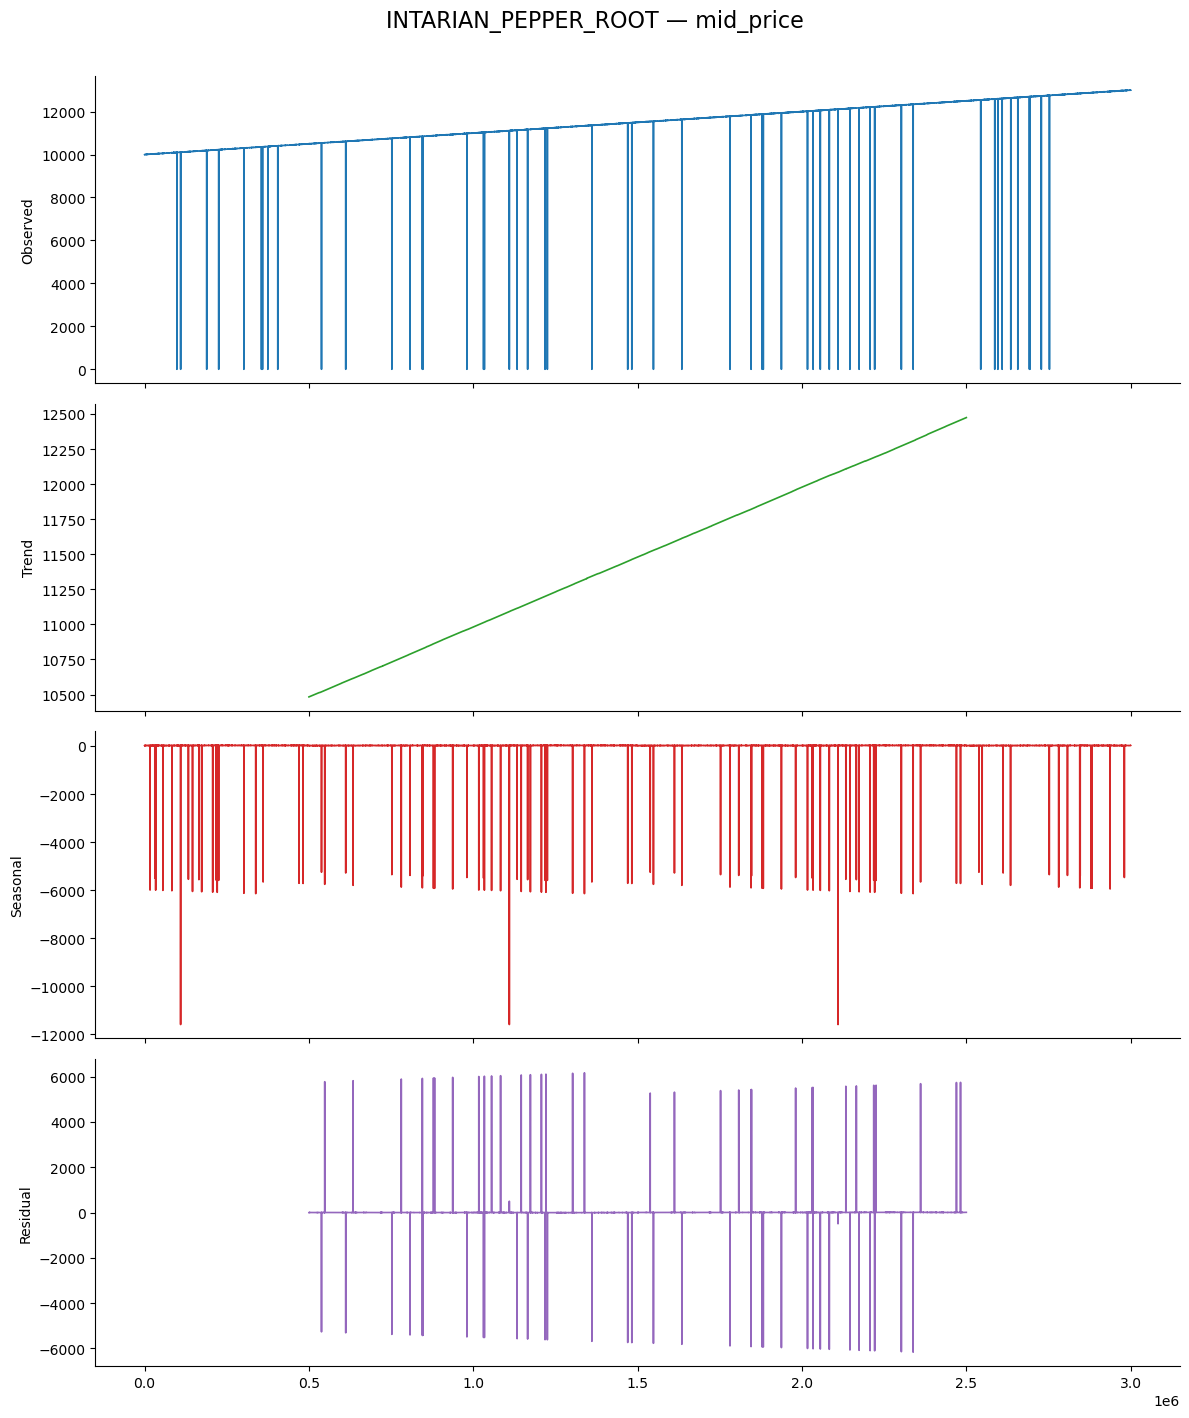

In [7]:
product = "INTARIAN_PEPPER_ROOT"

sub = (
    prices[prices["product"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
ts = sub["mid_price"].dropna()
period = min(n_ticks_per_day, len(ts) // 2)

result = seasonal_decompose(ts, model="additive", period=period)
plot_decomposition_subplots(result, f"{product} — mid_price")


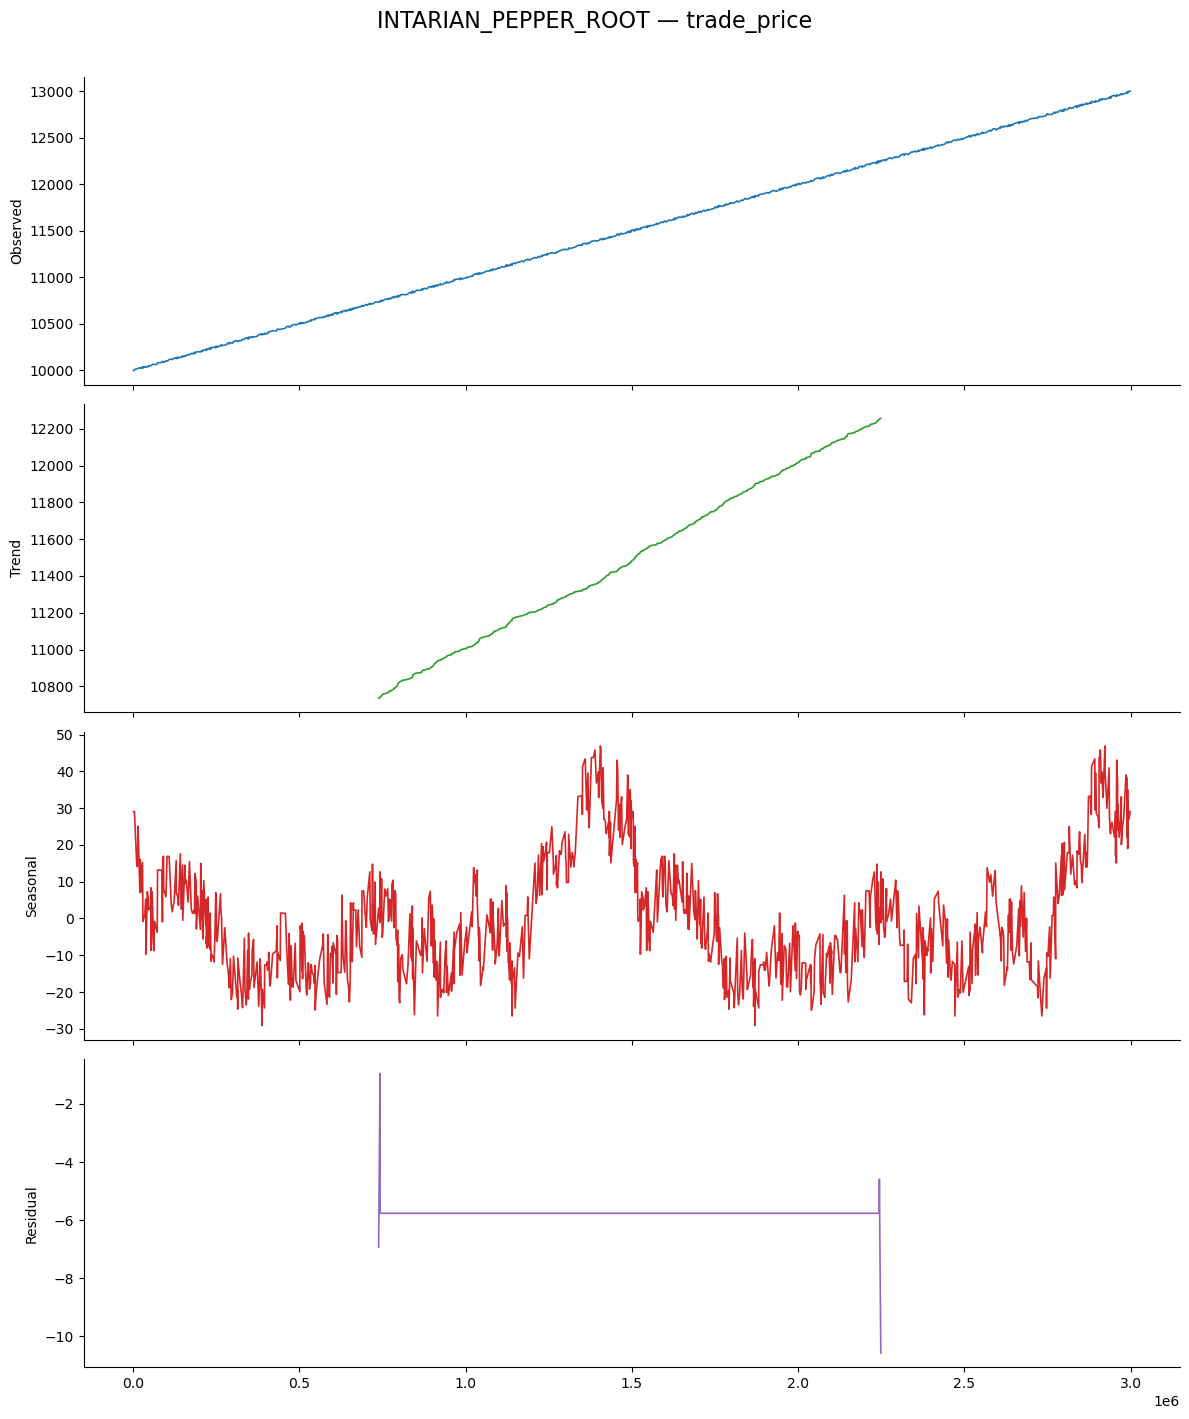

In [8]:
product = "INTARIAN_PEPPER_ROOT"

tsub = (
    trades[trades["symbol"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
trade_ts = tsub["price"].dropna()
trade_period = min(n_ticks_per_day, len(trade_ts) // 2)

trade_result = seasonal_decompose(trade_ts, model="additive", period=trade_period)
plot_decomposition_subplots(trade_result, f"{product} — trade_price")


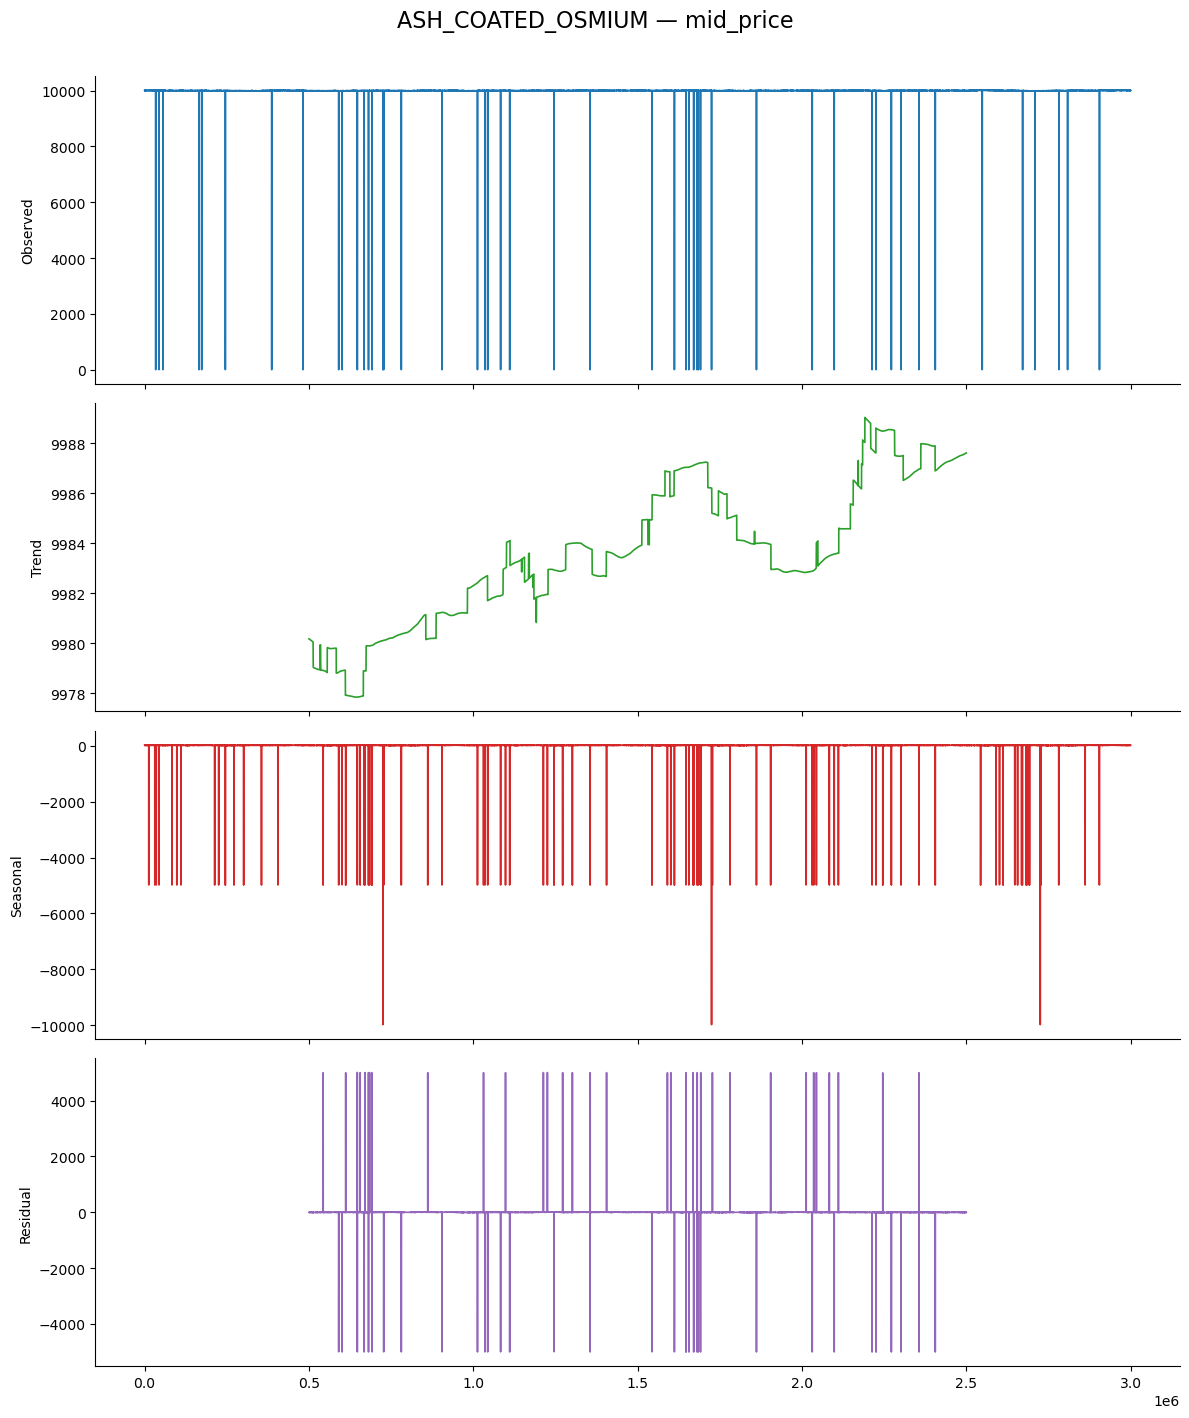

In [9]:
product = "ASH_COATED_OSMIUM"

sub = (
    prices[prices["product"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
ts = sub["mid_price"].dropna()
period = min(n_ticks_per_day, len(ts) // 2)

result = seasonal_decompose(ts, model="additive", period=period)
plot_decomposition_subplots(result, f"{product} — mid_price")


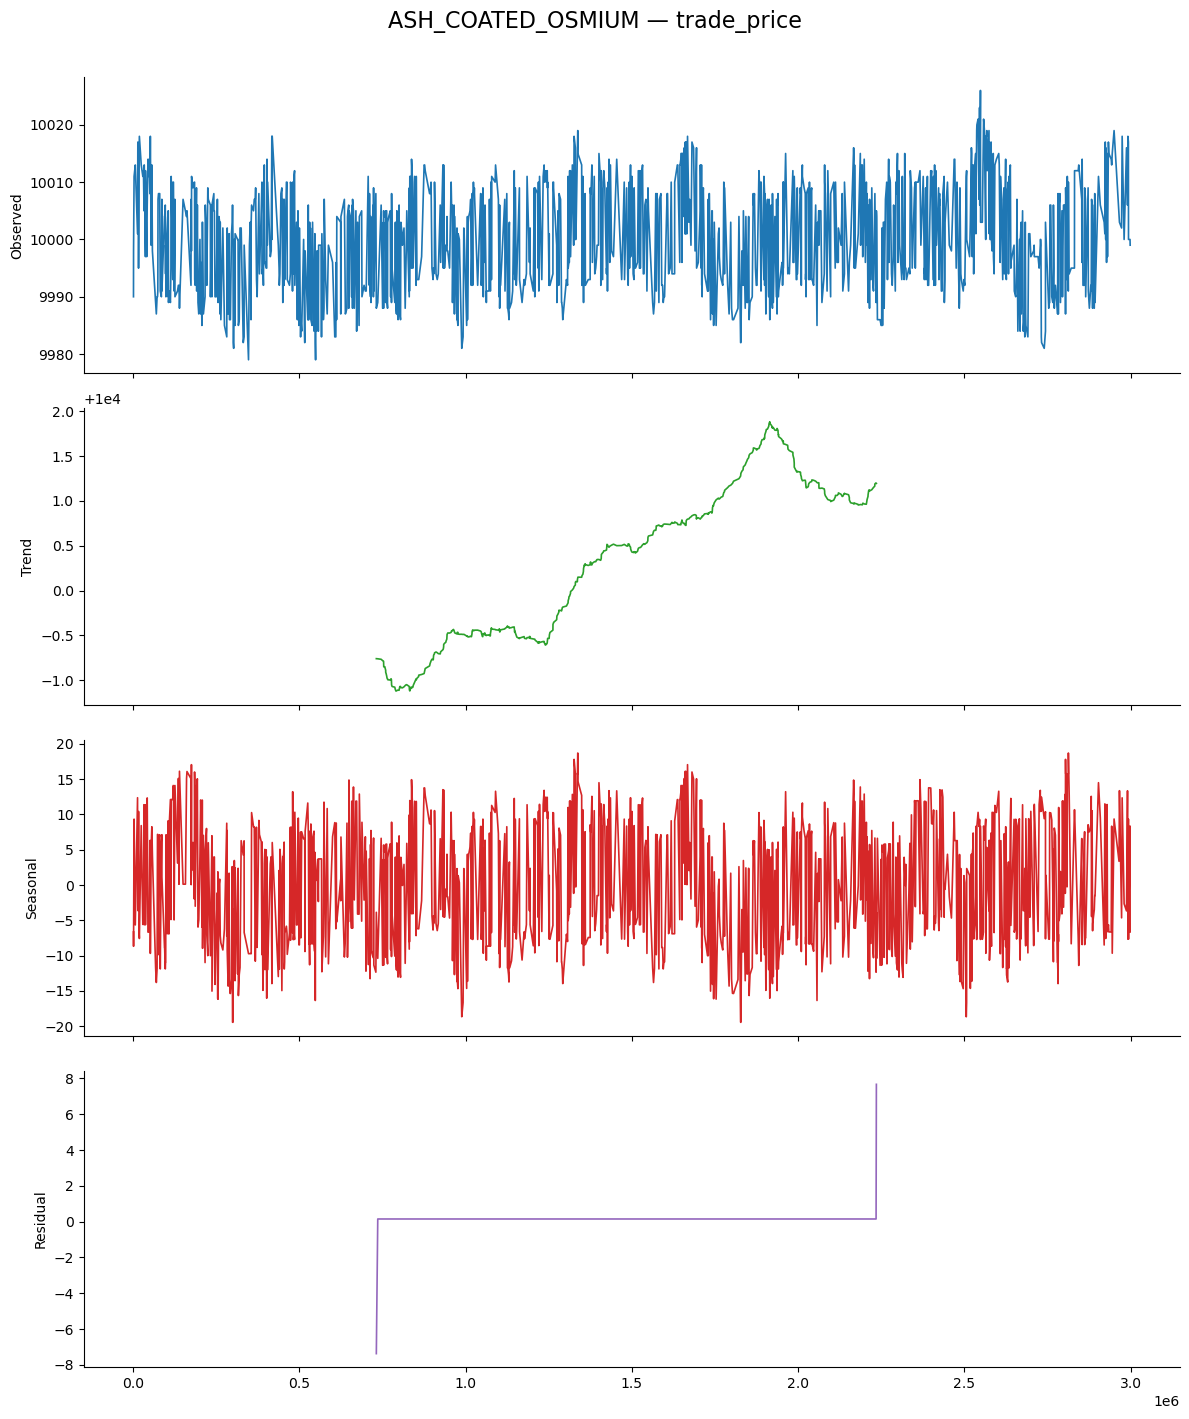

In [10]:
product = "ASH_COATED_OSMIUM"

tsub = (
    trades[trades["symbol"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
trade_ts = tsub["price"].dropna()
trade_period = min(n_ticks_per_day, len(trade_ts) // 2)

trade_result = seasonal_decompose(trade_ts, model="additive", period=trade_period)
plot_decomposition_subplots(trade_result, f"{product} — trade_price")


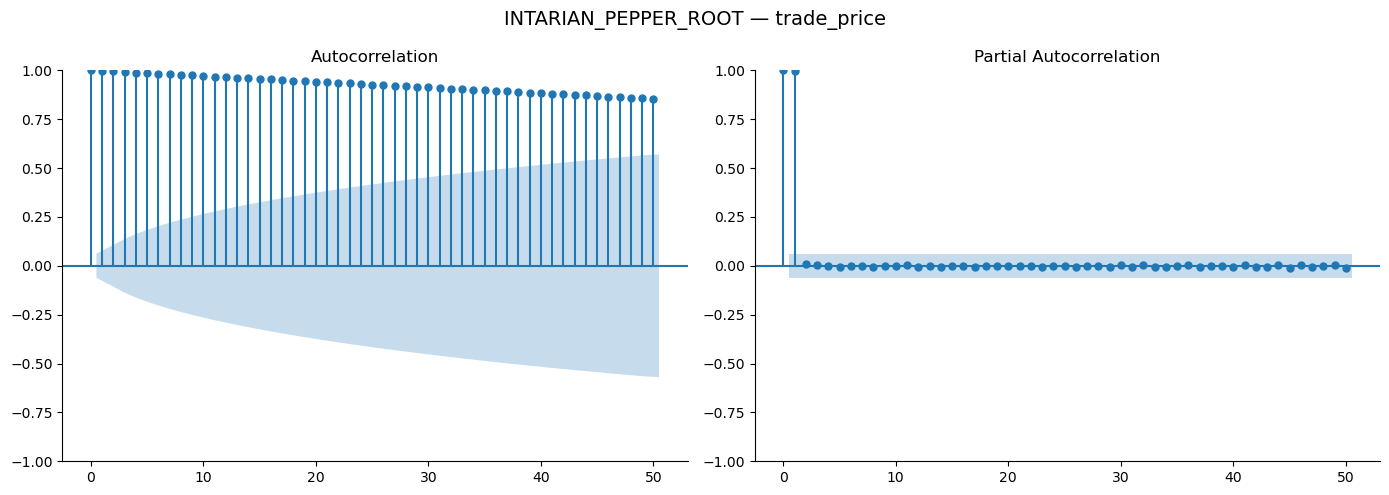

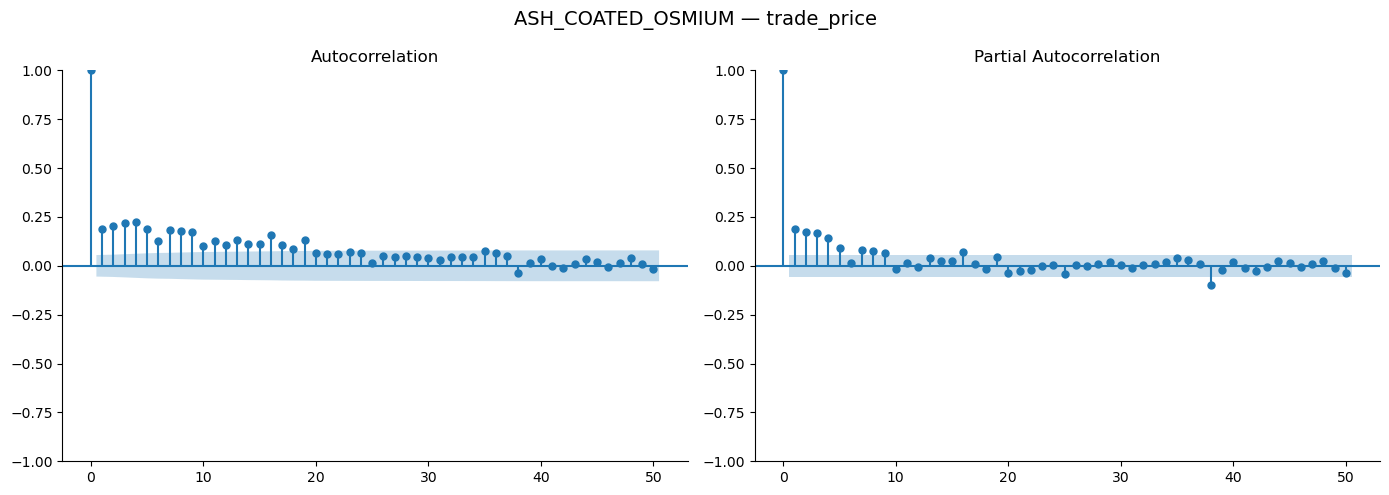

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for product in ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]:
    tsub = (
        trades[trades["symbol"] == product]
        .sort_values("global_ts")
        .set_index("global_ts")
    )
    trade_ts = tsub["price"].dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(trade_ts, lags=50, ax=ax1)
    plot_pacf(trade_ts, lags=50, ax=ax2)
    fig.suptitle(f"{product} — trade_price", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()


=== INTARIAN_PEPPER_ROOT ===
Raw ADF p-value:  0.975086
Diff ADF p-value: 0.000000


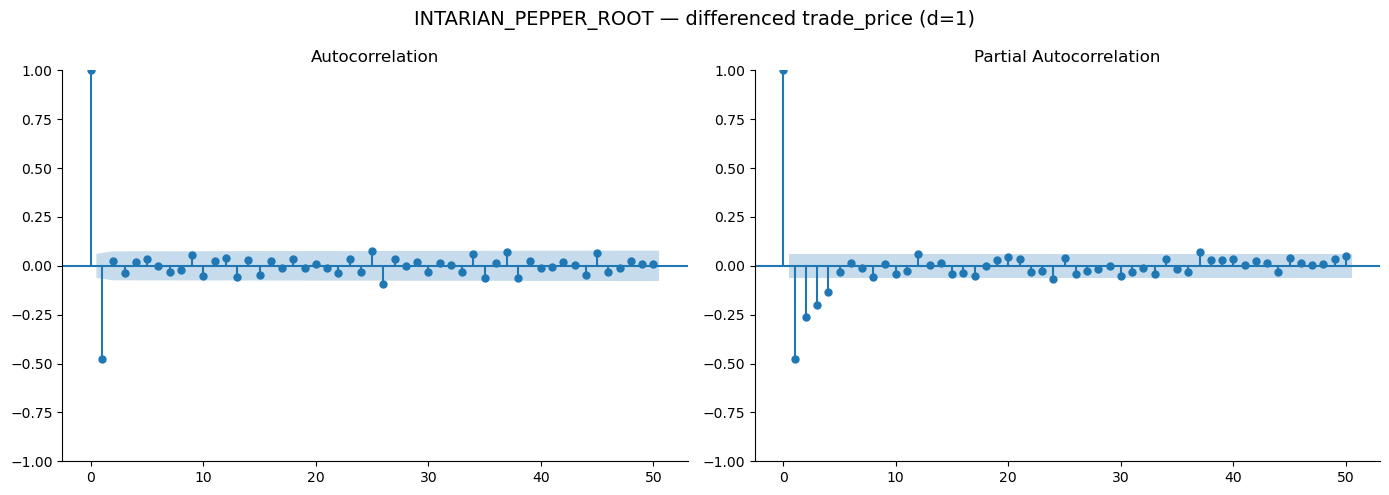


=== ASH_COATED_OSMIUM ===
Raw ADF p-value:  0.000000
Diff ADF p-value: 0.000000


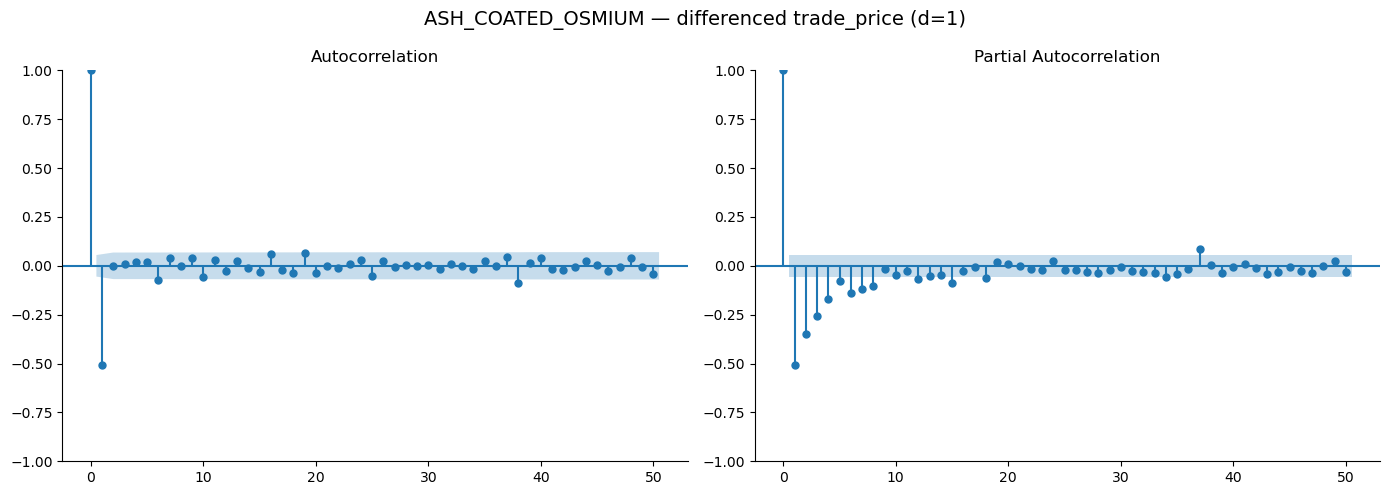

In [12]:
from statsmodels.tsa.stattools import adfuller

for product in ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]:
    tsub = (
        trades[trades["symbol"] == product]
        .sort_values("global_ts")
        .set_index("global_ts")
    )
    trade_ts = tsub["price"].dropna()
    diff_ts = trade_ts.diff().dropna()

    print(f"\n=== {product} ===")
    print(f"Raw ADF p-value:  {adfuller(trade_ts)[1]:.6f}")
    print(f"Diff ADF p-value: {adfuller(diff_ts)[1]:.6f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(diff_ts, lags=50, ax=ax1)
    plot_pacf(diff_ts, lags=50, ax=ax2)
    fig.suptitle(f"{product} — differenced trade_price (d=1)", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

product = "INTARIAN_PEPPER_ROOT"
tsub = (
    trades[trades["symbol"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
trade_ts = tsub["price"].dropna()

split = int(len(trade_ts) * 0.8)
train, test = trade_ts[:split], trade_ts[split:]

rows = []
for order in [(2, 1, 1), (3, 1, 1), (3,2,1), (3,3,1)]:
    fit = ARIMA(train, order=order).fit()
    forecast = fit.forecast(steps=len(test))
    rows.append({
        "Model": f"ARIMA{order}",
        "AIC": round(fit.aic, 1),
        "BIC": round(fit.bic, 1),
        "MAE": round(mean_absolute_error(test, forecast), 2),
        "RMSE": round(np.sqrt(mean_squared_error(test, forecast)), 2),
    })

pd.DataFrame(rows).set_index("Model")

,AIC,BIC,MAE,RMSE
Model,,,,
"ARIMA(2, 1, 1)",5615.8,5634.6,39.80,43.60
"ARIMA(3, 1, 1)",5571.7,5595.2,39.15,43.00
"ARIMA(3, 2, 1)",5531.6,5555.1,37.68,41.62
"ARIMA(3, 3, 1)",5885.7,5909.1,100.02,111.30


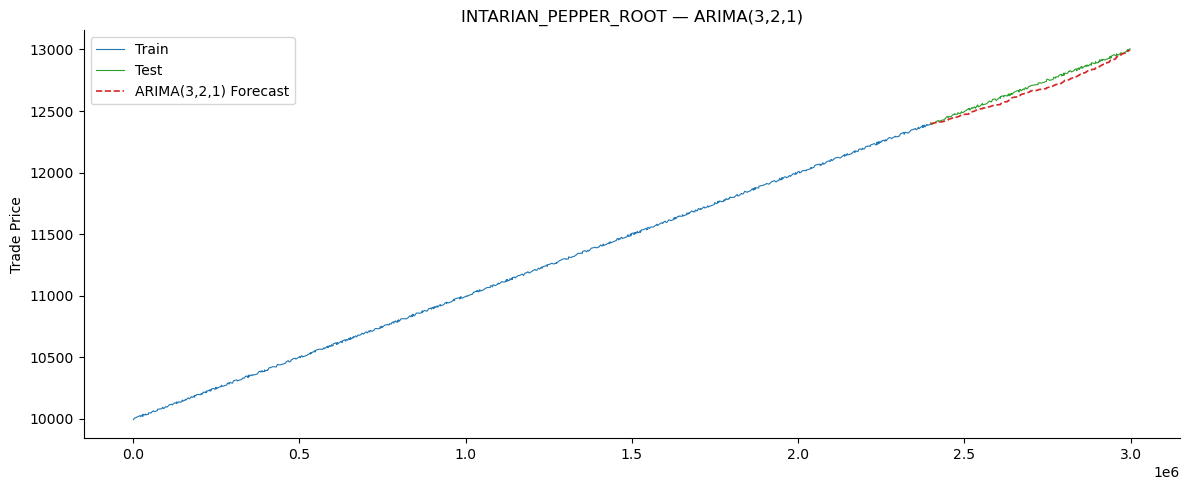

In [14]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

product = "INTARIAN_PEPPER_ROOT"
tsub = (
    trades[trades["symbol"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
trade_ts = tsub["price"].dropna()

split = int(len(trade_ts) * 0.8)
train, test = trade_ts[:split], trade_ts[split:]

fit = ARIMA(train, order=(3, 2, 1)).fit()
forecast = fit.forecast(steps=len(test))
forecast.index = test.index

fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, label="Train", color="#1f77b4", linewidth=0.8)
test.plot(ax=ax, label="Test", color="#2ca02c", linewidth=0.8)
forecast.plot(ax=ax, label="ARIMA(3,2,1) Forecast", color="#d62728", linewidth=1.2, linestyle="--")
ax.set_title(f"{product} — ARIMA(3,2,1)")
ax.set_ylabel("Trade Price")
ax.set_xlabel("")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

product = "INTARIAN_PEPPER_ROOT"
tsub = (
    trades[trades["symbol"] == product]
    .sort_values("global_ts")
    .set_index("global_ts")
)
trade_ts = tsub["price"].dropna()

split = int(len(trade_ts) * 0.8)
train, test = trade_ts[:split], trade_ts[split:]

# Linear regression: price ~ time index
X_train = np.arange(len(train)).reshape(-1, 1)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

lr = LinearRegression().fit(X_train, train.values)
lr_forecast = pd.Series(lr.predict(X_test), index=test.index)



# Comparison table
rows = []
for name, fcast in [("ARIMA(3,2,1)", forecast), ("Linear Regression", lr_forecast)]:
    rows.append({
        "Model": name,
        "MAE": round(mean_absolute_error(test, fcast), 2),
        "RMSE": round(np.sqrt(mean_squared_error(test, fcast)), 2),
    })
display(pd.DataFrame(rows).set_index("Model"))

,MAE,RMSE
Model,,
"ARIMA(3,2,1)",37.68,41.62
Linear Regression,46.91,50.27
